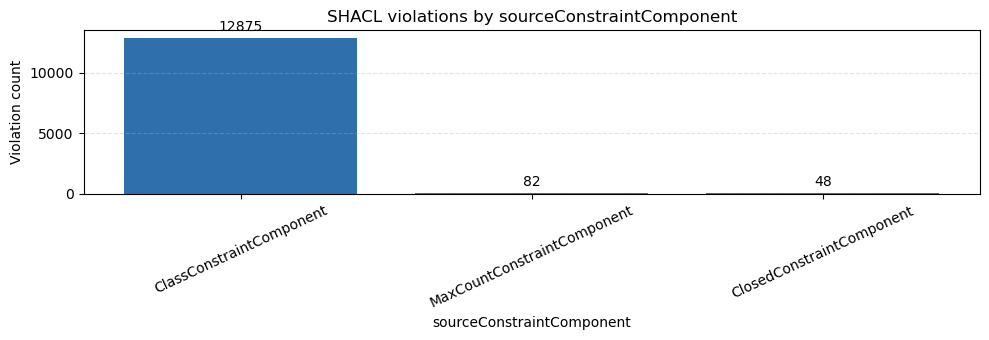

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
component_counts = shacl_violation_distribution.collect_source_constraint_component_counts(str(run_directory))

if not component_counts:
    print("No SHACL violations found.")
else:
    ordered_items = component_counts.most_common()
    labels = [label for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.5 * len(labels))))
    bars = ax.bar(labels, values, color="#2f6fab")
    ax.set_title("SHACL violations by sourceConstraintComponent")
    ax.set_xlabel("sourceConstraintComponent")
    ax.set_ylabel("Violation count")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

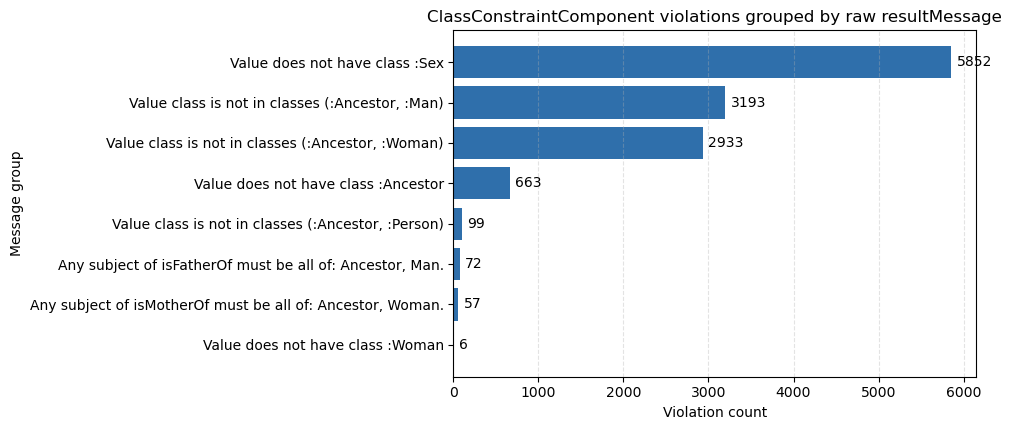

In [2]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))

if not message_counts:
    print("No ClassConstraintComponent violations found.")
else:
    ordered_items = message_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#2f6fab")
    ax.set_title("ClassConstraintComponent violations grouped by raw resultMessage")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Message group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

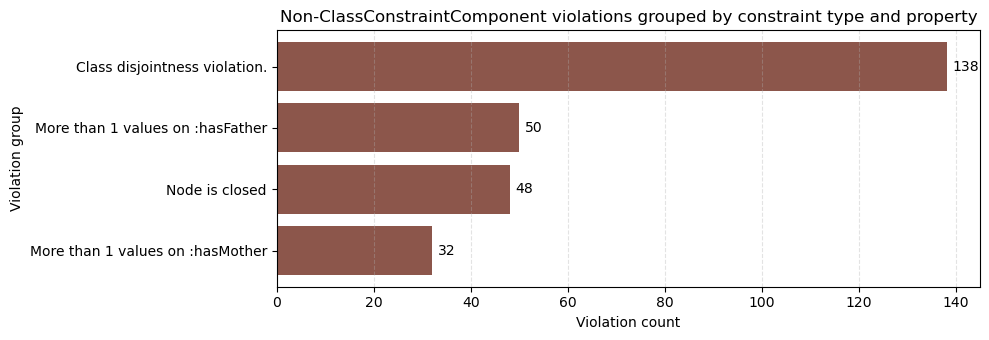

In [4]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
other_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_counts = shacl_violation_distribution.reorganize_non_class_violations(other_message_counts)

if not reorganized_counts:
    print("No non-ClassConstraintComponent violations found.")
else:
    ordered_items = reorganized_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#8c564b")
    ax.set_title("Non-ClassConstraintComponent violations grouped by constraint type and property")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Violation group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

In [11]:
from pathlib import Path
import importlib
import sys

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
violations_by_message = shacl_violation_distribution.collect_non_class_violations_by_task(str(run_directory))

# Filter for class disjointness violations (case-insensitive search)
class_disjointness_tasks = set()
for message, tasks in violations_by_message.items():
    if "disjoint" in message.lower():
        class_disjointness_tasks.update(tasks)

# Filter for max count violations
max_count_tasks = set()
for message, tasks in violations_by_message.items():
    if "More than" in message:
        max_count_tasks.update(tasks)

print(f"Number of different tasks with class disjointness violations: {len(class_disjointness_tasks)}")
print(f"Number of different tasks with max count violations: {len(max_count_tasks)}")

Number of different tasks with class disjointness violations: 6
Number of different tasks with max count violations: 21


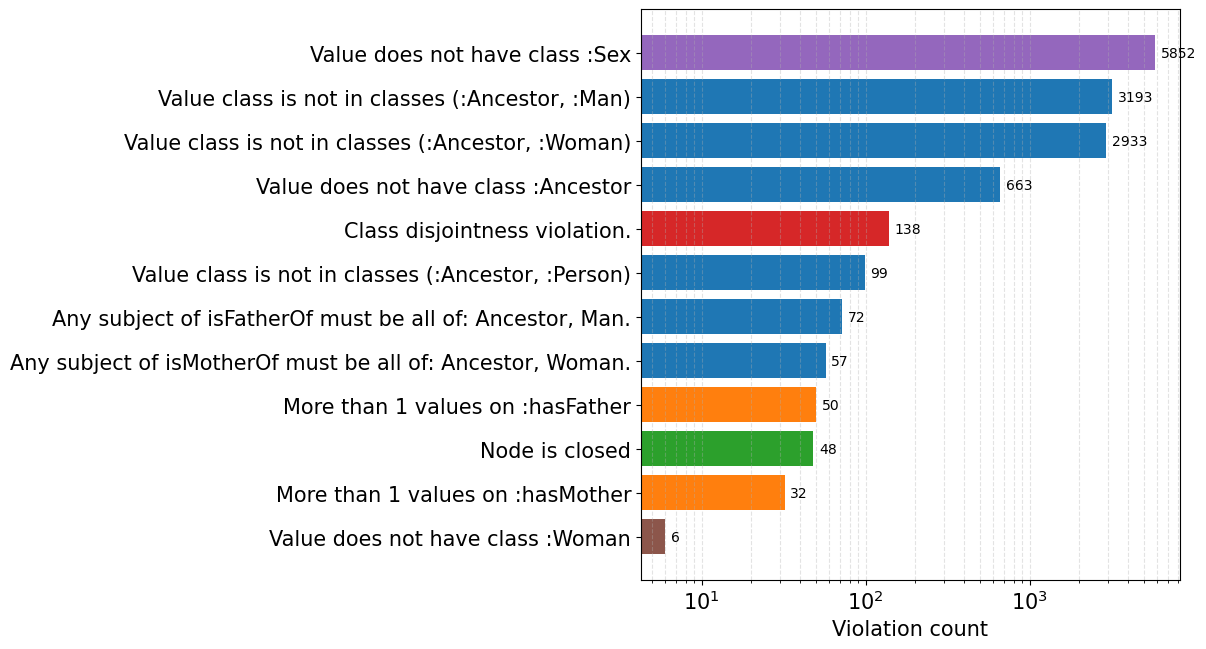

Saved PDF to /Users/momssun/thesis-code/results/royalty_gemini_with_shacl/combined_message_groups.pdf


In [15]:
from pathlib import Path
import importlib
import sys
from collections import Counter
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
class_message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))
non_class_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_non_class_counts = shacl_violation_distribution.reorganize_non_class_violations(non_class_message_counts)
combined_message_counts = Counter(class_message_counts) + Counter(reorganized_non_class_counts)

if not combined_message_counts:
    print("No SHACL violations found.")
else:
    ordered_items = combined_message_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    ancestor_bar_positions = {2, 3, 4, 6, 7, 8}
    more_than_bar_positions = {9, 11}
    distinct_bar_colors = {
        1: "#9467bd",
        5: "#d62728",
        10: "#2ca02c",
        12: "#8c564b",
    }
    ancestor_color = "#1f77b4"
    more_than_color = "#ff7f0e"
    bar_colors = []

    for index, label in enumerate(labels, start=1):
        if index in ancestor_bar_positions:
            bar_colors.append(ancestor_color)
        elif index in more_than_bar_positions:
            bar_colors.append(more_than_color)
        else:
            bar_colors.append(distinct_bar_colors.get(index, "#7f7f7f"))

    fig, ax = plt.subplots(figsize=(12, max(4.0, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color=bar_colors)
    ax.set_xlabel("Violation count", fontsize=15)
    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35, which="both")
    ax.tick_params(axis="both", labelsize=15)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    output_pdf = workspace_root / "results" / "royalty_gemini_with_shacl" / "combined_message_groups.pdf"
    fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    print(f"Saved PDF to {output_pdf}")

In [2]:
from collections import Counter
from pathlib import Path
import importlib
import json
import sys

from rdflib import Graph, SH, RDF

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
closed_violations = Counter()

for graphs_path in sorted(run_directory.rglob("artifacts/graphs.json")):
    try:
        records = json.loads(graphs_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        continue

    if not isinstance(records, list):
        continue

    for record in records:
        if not isinstance(record, dict):
            continue

        if record.get("graph_type") != "validation_graph":
            continue

        graph_text = record.get("graph")
        if not isinstance(graph_text, str):
            continue

        try:
            graph = Graph()
            graph.parse(data=graph_text, format="turtle")
        except Exception:
            continue

        for result_node in graph.subjects(RDF.type, SH.ValidationResult):
            message = graph.value(result_node, SH.resultMessage)
            path = graph.value(result_node, SH.resultPath)
            component = graph.value(result_node, SH.sourceConstraintComponent)

            if component != SH.ClosedConstraintComponent:
                continue

            if message is None:
                continue

            closed_violations[(str(message), str(path) if path is not None else "(no path)")] += 1

if not closed_violations:
    print("No Node is closed violations found.")
else:
    print("Node is closed violations with path component:")
    for (message, path), count in closed_violations.most_common():
        print(f"- {count}x {message} | path: {path}")
    print(f"Total combined into Node is closed: {sum(closed_violations.values())}")

Node is closed violations with path component:
- 4x Node data:Ernest_Augustus_Crown_Prince_of_Hanover is closed. It cannot have value: data:George_V_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 4x Node data:Prince_Ernest_Augustus_Duke_of_Cumberland_and_Teviotdale is closed. It cannot have value: data:George_III_of_the_United_Kingdom | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:Prince_Ernest_Augustus_II is closed. It cannot have value: data:Ernest_Augustus_Crown_Prince_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:Prince_Ernest_Augustus_II is closed. It cannot have value: data:Princess_Victoria_Louise_of_Prussia | path: http://example.com/family_TBOX.ttl#hasRelation
- 2x Node data:George_William is closed. It cannot have value: data:Ernest_Augustus_Crown_Prince_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:George_William is closed. It cannot have value: data:Princess_Thyra_of_De

In [4]:
from pathlib import Path
import importlib
import json
import sys
from collections import Counter, defaultdict

from rdflib import Graph, RDF, SH

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import experiments.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"


def _to_qname(graph: Graph, term) -> str:
    if term is None:
        return "(none)"
    try:
        return graph.namespace_manager.normalizeUri(term)
    except Exception:
        return str(term)


if not run_directory.exists():
    print(f"Run directory not found: {run_directory}")
else:
    for graphs_path in sorted(run_directory.rglob("artifacts/graphs.json")):
        try:
            records = json.loads(graphs_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        if not isinstance(records, list):
            continue

        data_graph_snapshots = {
            (record.get("iteration"), record.get("tool_call_id")): record
            for record in records
            if isinstance(record, dict)
            and record.get("graph_type") == "data_graph"
            and record.get("source") == "pre_validation"
            and isinstance(record.get("graph"), str)
        }

        for record in records:
            if not isinstance(record, dict):
                continue

            if record.get("graph_type") != "validation_graph":
                continue

            graph_text = record.get("graph")
            if not isinstance(graph_text, str):
                continue

            try:
                validation_graph = Graph()
                validation_graph.parse(data=graph_text, format="turtle")
            except Exception:
                continue

            closed_result_nodes = list(validation_graph.subjects(SH.sourceConstraintComponent, SH.ClosedConstraintComponent))
            if not closed_result_nodes:
                continue

            snapshot_key = (record.get("iteration"), record.get("tool_call_id"))
            data_snapshot = data_graph_snapshots.get(snapshot_key)
            if data_snapshot is None:
                print(f"No pre-validation data graph found for {graphs_path} | iteration={record.get('iteration')} | tool_call_id={record.get('tool_call_id')}")
                continue

            try:
                data_graph = Graph()
                data_graph.parse(data=data_snapshot["graph"], format="turtle")
            except Exception:
                continue

            focus_node_summary = defaultdict(lambda: {"count": 0, "paths": set(), "messages": set()})
            for result_node in closed_result_nodes:
                focus_node = validation_graph.value(result_node, SH.focusNode)
                path = validation_graph.value(result_node, SH.resultPath)
                message = validation_graph.value(result_node, SH.resultMessage)
                focus_node_summary[focus_node]["count"] += 1
                if path is not None:
                    focus_node_summary[focus_node]["paths"].add(_to_qname(validation_graph, path))
                if message is not None:
                    focus_node_summary[focus_node]["messages"].add(str(message))

            print(f"Validation graph: {graphs_path}")
            for focus_node, summary in sorted(focus_node_summary.items(), key=lambda item: _to_qname(data_graph, item[0])):
                focus_classes = sorted(
                    {
                        _to_qname(data_graph, class_term)
                        for class_term in data_graph.objects(focus_node, RDF.type)
                    }
                )
                focus_display = _to_qname(data_graph, focus_node)
                paths_display = ", ".join(sorted(summary["paths"])) if summary["paths"] else "(none)"
                print(f"- focus node: {focus_display}")
                print(f"  closed violations: {summary['count']}")
                print(f"  path(s): {paths_display}")
                print(f"  classes in data graph: {', '.join(focus_classes) if focus_classes else '(none)'}")
            print()

Validation graph: /Users/momssun/thesis-code/results/royalty_gemini_with_shacl/114_114/artifacts/graphs.json
- focus node: data:John_Knatchbull
  closed violations: 1
  path(s): :isFatherOf
  classes in data graph: :Ancestor, :Man, :Person, :Sex
- focus node: data:Norton_Louis_Philip_Knatchbull
  closed violations: 5
  path(s): :hasBrother, :hasFather, :hasMother, :hasRelation
  classes in data graph: :Man, :Person, :Sex
- focus node: data:Patricia_Knatchbull
  closed violations: 1
  path(s): :isMotherOf
  classes in data graph: :Ancestor, :Person, :Sex, :Woman
- focus node: data:Penelope_Meredith_Eastwood
  closed violations: 2
  path(s): :hasFather, :hasMother
  classes in data graph: :Person, :Sex, :Woman

No pre-validation data graph found for /Users/momssun/thesis-code/results/royalty_gemini_with_shacl/129_129/artifacts/graphs.json | iteration=4 | tool_call_id=57c1eb1b-1b41-4044-97f8-ca995389783e
No pre-validation data graph found for /Users/momssun/thesis-code/results/royalty_gem

In [10]:
from pathlib import Path
import importlib
import json
import sys
from collections import defaultdict

from rdflib import Graph, RDF, SH

workspace_root = Path.cwd()
if not (workspace_root / "experiments").exists() and (workspace_root.parent / "experiments").exists():
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"


def _to_qname(graph: Graph, term) -> str:
    if term is None:
        return "(none)"
    try:
        return graph.namespace_manager.normalizeUri(term)
    except Exception:
        return str(term)


if not run_directory.exists():
    print(f"Run directory not found: {run_directory}")
else:
    for graphs_path in sorted(run_directory.rglob("artifacts/graphs.json")):
        try:
            records = json.loads(graphs_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        if not isinstance(records, list):
            continue

        data_graph_snapshots = {
            (record.get("iteration"), record.get("tool_call_id")): record
            for record in records
            if isinstance(record, dict)
            and record.get("graph_type") == "data_graph"
            and record.get("source") == "pre_validation"
            and isinstance(record.get("graph"), str)
        }

        for record in records:
            if not isinstance(record, dict):
                continue

            if record.get("graph_type") != "validation_graph":
                continue

            graph_text = record.get("graph")
            if not isinstance(graph_text, str):
                continue

            try:
                validation_graph = Graph()
                validation_graph.parse(data=graph_text, format="turtle")
            except Exception:
                continue

            class_nodes = []
            for result_node in validation_graph.subjects(RDF.type, SH.ValidationResult):
                message = validation_graph.value(result_node, SH.resultMessage)
                component = validation_graph.value(result_node, SH.sourceConstraintComponent)
                comp_str = str(component) if component is not None else ""
                if (message and "disjoint" in str(message).lower()) or ("disjoint" in comp_str.lower()):
                    class_nodes.append(result_node)

            if not class_nodes:
                continue

            snapshot_key = (record.get("iteration"), record.get("tool_call_id"))
            data_snapshot = data_graph_snapshots.get(snapshot_key)
            if data_snapshot is None:
                print(f"No pre-validation data graph found for {graphs_path} | iteration={record.get('iteration')} | tool_call_id={record.get('tool_call_id')}")
                continue

            try:
                data_graph = Graph()
                data_graph.parse(data=data_snapshot["graph"], format="turtle")
            except Exception:
                continue

            focus_summary = defaultdict(lambda: {"count": 0, "paths": set(), "messages": set()})
            for rn in class_nodes:
                focus = validation_graph.value(rn, SH.focusNode)
                path = validation_graph.value(rn, SH.resultPath)
                msg = validation_graph.value(rn, SH.resultMessage)
                focus_summary[focus]["count"] += 1
                if path is not None:
                    focus_summary[focus]["paths"].add(_to_qname(validation_graph, path))
                if msg is not None:
                    focus_summary[focus]["messages"].add(str(msg))

            print(f"Validation graph: {graphs_path}")
            for focus, summary in sorted(focus_summary.items(), key=lambda item: _to_qname(data_graph, item[0])):
                classes = sorted({ _to_qname(data_graph, c) for c in data_graph.objects(focus, RDF.type) })
                print(f"- focus node: {_to_qname(data_graph, focus)}")
                print(f"  class-disjointness violations: {summary['count']}")
                print(f"  path(s): {', '.join(sorted(summary['paths'])) if summary['paths'] else '(none)'}")
                print(f"  message(s): {', '.join(sorted(summary['messages'])) if summary['messages'] else '(none)'}")
                print(f"  classes in data graph: {', '.join(classes) if classes else '(none)'}")
            print()

Validation graph: /Users/momssun/thesis-code/results/royalty_gemini_with_shacl/114_114/artifacts/graphs.json
- focus node: data:Doreen_Knatchbull
  class-disjointness violations: 3
  path(s): (none)
  message(s): Class disjointness violation.
  classes in data graph: :Person, :Sex, :Woman
- focus node: data:Eugenie_Lady_Nuttall
  class-disjointness violations: 3
  path(s): (none)
  message(s): Class disjointness violation.
  classes in data graph: :Person, :Sex, :Woman
- focus node: data:John_Knatchbull
  class-disjointness violations: 4
  path(s): (none)
  message(s): Class disjointness violation.
  classes in data graph: :Ancestor, :Man, :Person, :Sex
- focus node: data:Louis_Mountbatten
  class-disjointness violations: 3
  path(s): (none)
  message(s): Class disjointness violation.
  classes in data graph: :Man, :Person, :Sex
- focus node: data:Marian_Elizabeth
  class-disjointness violations: 4
  path(s): (none)
  message(s): Class disjointness violation.
  classes in data graph: :